In [1]:
import torch
from torchvision import transforms, models
from torchvision import transforms
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:

from utils.Config import Config

cfg = Config.from_yaml("config.yaml")
cfg

Config(model_name='CustomResNet18_SGD_HeadCrop', resume_training=True, save_on_drive=False, batch_size=32, download_data=True, use_augmentation=True, use_head_crop=False, use_segmentation=True, fine_tuning=False, loss=<LossType.CROSS_ENTROPY: 'CrossEntropy'>, epochs=50, patience=25, learning_rate=0.01, optimizer=<OptimizerType.SGD: 'SGD'>, weight_decay=0.0005, momentum=0.9, nesterov=True, label_smoothing=0.1, scheduler=<SchedulerType.ONE_CYCLE: 'OneCycleLR'>, scheduler_patience=3)

In [3]:
"""
Questa cella serve per salvare i modelli direttamente su Google Drive, è stata utilizzata in 
quanto Colab tende a scollegare il runtime casualmente, senza un salvataggio esterno
si potrebbero perdere i dati del modello, se non si savla una copia prima che questo si verifichi.
"""

import os
from google.colab import drive

if(cfg.save_on_drive):
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

    DRIVE_CHECKPOINTS_DIR = '/content/drive/MyDrive/checkpoints'

    print(f"I checkpoint verranno salvati in modo sicuro qui: {DRIVE_CHECKPOINTS_DIR}")

else:
    DRIVE_CHECKPOINTS_DIR = '/checkpoints'



ModuleNotFoundError: No module named 'google'

In [3]:
from utils.dataDownloader import download_data

if(cfg.download_data):
    download_data()

In [4]:

# Statistiche standard di ImageNet (usate da ResNet/VGG)
# È fondamentale usare queste se fai Transfer Learning
mean_stats = [0.485, 0.456, 0.406]
std_stats  = [0.229, 0.224, 0.225]


"""
Per i dati di test ricorriamo al Data Augmentation, una metodologia che consente di variare
il contenuto di dataset di piccole e medie dimensioni introducendo delle modifiche alle 
immagini, con lo scopo di migliorare la generalizzazione e ridurre overfitting.
"""

if(cfg.use_augmentation):
    train_transforms = transforms.Compose([
        transforms.Resize((256, 256)), 
    
    transforms.RandomCrop(224, padding=4), 
    
    transforms.RandomHorizontalFlip(),
    
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    
    transforms.ToTensor(),
    transforms.Normalize(mean_stats, std_stats)
    ])

else:
    train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),   
    transforms.ToTensor(),
    transforms.Normalize(mean_stats, std_stats) 
    ])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),            
    transforms.Normalize(mean_stats, std_stats)
])

In [7]:
from utils.OxfordPets import OxfordPetsDataset
from sklearn.model_selection import train_test_split

"""
Quando componiamo i set di dati che verranno utilizzati nella fase di addestramento, validazione
e test dividiamo i dati in modo che questi abbiano rispettivamente il 70%, il 15% ed il 15% del totale.

L'opzione "stratify" consente di dividere equamente le classi nei set, in modo che una divisione
sfortunata porti ad avere classi quasi del tutto assenti da uno dei set, invalidando il riusltato.

Impostare il "random_state" serve nei casi in cui si intende riprendere l'addestramento di un modello
già precedentemente addestrato; se non vi fosse, dati che precedentemente sono stati destinati all'addestramento
ora potrebbero venire inclusi nel set di validazione, o peggio in quello di test, generando il fenomeno
del Data Leakage, in cui il modello viene validato su dati che ha già visto, performando meglio rispetto
a come dovrebbe, avendo memorizzato alcune immagini.
"""

full_train_ds = OxfordPetsDataset(root_dir='res', transform=train_transforms, use_head_crop=cfg.use_head_crop, use_segmentation=cfg.use_segmentation)

full_test_ds = OxfordPetsDataset(root_dir='res', transform=test_transforms, use_head_crop=cfg.use_head_crop,use_segmentation=cfg.use_segmentation)

targets = full_train_ds.targets 
indices = list(range(len(full_train_ds)))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, shuffle=True, random_state=42, stratify=targets
)

temp_targets = [targets[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, shuffle=True, random_state=42, stratify=temp_targets
)


train_dataset = Subset(full_train_ds, train_idx)

val_dataset   = Subset(full_test_ds, val_idx)

test_dataset  = Subset(full_test_ds, test_idx)

print(f"Train: {len(train_dataset)} immagini")
print(f"Val:   {len(val_dataset)} immagini")
print(f"Test:  {len(test_dataset)} immagini")

Train: 5144 immagini
Val:   1102 immagini
Test:  1103 immagini


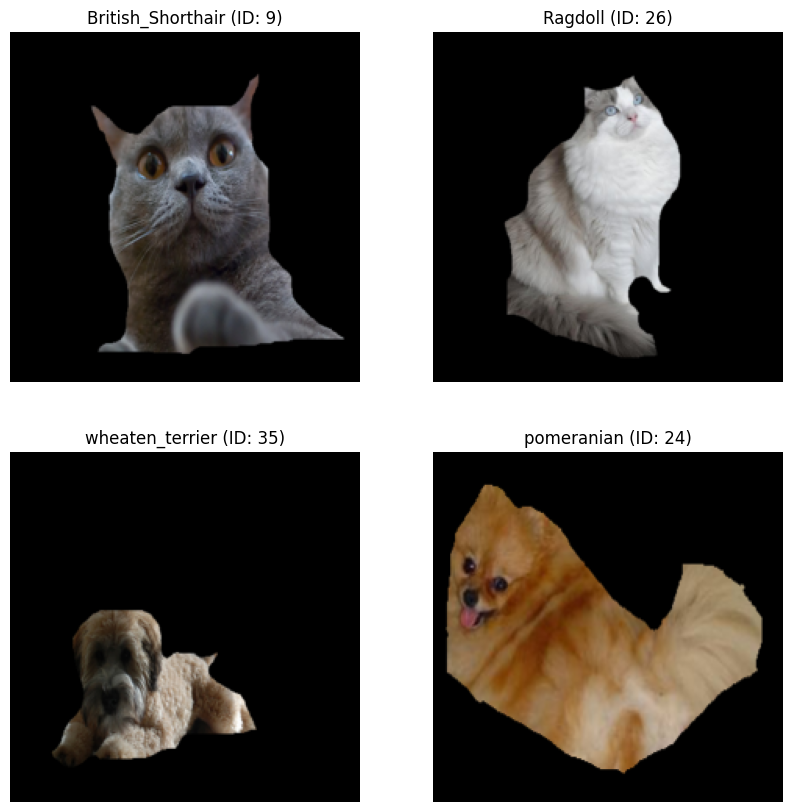

In [8]:

# Mostriamo alcune delle immagini per verificare che siano presenti
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

idx_to_class = {}
with open('res/annotations/list.txt', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split()
        if len(parts) >= 2:
            breed_name = parts[0].rsplit('_', 1)[0]
            class_id = int(parts[1]) - 1
            idx_to_class[class_id] = breed_name

figure = plt.figure(figsize=(10, 10))
cols, rows = 2, 2

for i in range(1, cols * rows + 1):
    # Le prendiamo dal test set direttamente
    sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
    img, label = test_dataset[sample_idx]
    
    figure.add_subplot(rows, cols, i)
    plt.title(f"{idx_to_class.get(label, label)} (ID: {label})")
    plt.axis("off")
    
    # Operazioni per visualizzare
    img_np = img.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    plt.imshow(img_np)

plt.show()

In [ ]:

"""
In questo punto del codice andrà incollato il modello che si intende utilizzare. Occorre cambiare il nome della classe del modello, 
per farla combaciare con il nome presente nelle altre celle in cui viene utilizzato: CustomCNN.
Se si intende effettuare fine tuning di un modello esistente non è necessario.
"""

In [ ]:


"""
 Questa classe serve a modellare l'early stopping, quando la loss del training set diminuisce ma quella del validation set sale, 
 stiamo andando incontro al fenomeno dell'overfitting.
 Quando succede per un determinato numero di epoche fermiamo il training e consideriamo come modello allenato l'ultimo prima che iniziasse questo fenomeno.
"""

class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0):
        """
        Args:
            patience (int): Quante epoche aspettare dopo l'ultimo miglioramento.
            verbose (bool): Se True, stampa un messaggio a ogni miglioramento.
            delta (float): Minimo cambiamento da considerare come miglioramento.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            #Se non si migliora la performance sul set di validazione, aggiorniamo il contatore della pazienza
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            #Se invece si migliora, salviamo il modello e resettiamo la pazienza
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Salva il modello quando la validation loss diminuisce.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.best_model_wts = model.state_dict() # Salva i pesi in memoria
        self.val_loss_min = val_loss
    
    def load_best_weights(self, model):
        '''Carica i pesi migliori nel modello'''
        model.load_state_dict(self.best_model_wts)

In [ ]:
import torch

def atomic_save(checkpoint, filepath):
    """
    Funzione per salvare i modelli. Evita che si corrompa il salvataggio se 
    esso si interrompe a metà, rinomiando il file e sostituendolo al vecchio solo se il 
    caricamento risulta completo.
    Questo è stato particolarmente utile durante l'addestramento con Google Colab, che potrebbe
    disconnettere il runtime casualmente durante l'esecuzione, andando a corrompere il modello se questo
    si verfica proprio nel momento del salvataggio.
    """
    temp_path = filepath + ".tmp"
    
    try:
        torch.save(checkpoint, temp_path)
        
        if os.path.exists(temp_path):
            os.replace(temp_path, filepath)
            
    except Exception as e:
        print(f"ERRORE SALVATAGGIO DRIVE: {e}")
        # Pulizia
        if os.path.exists(temp_path):
            os.remove(temp_path)

In [ ]:
from torch.utils.data import DataLoader
import torch.optim as optim
from utils.Config import SchedulerType
import os

# Assicuriamoci che device sia definito
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def train_experiment(model, cfg, train_dataset, val_dataset):
    
    """
    Funzione di addestramento del modello. Grazie alle configurazioni consente un'esecuzione
    modulare, necessitando di cambi di configurazioni qualora volessero essere provate altri
    parametri.
    """

    print(f"Avvio esperimento: {cfg.model_name} su {device}")
    
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)

    #Ottimizzatore, funzione di loss e scheduler sono configurabili
    criterion = cfg.get_loss_fn()
    optimizer = cfg.init_optimizer(model.parameters())
    scheduler = cfg.init_scheduler(optimizer, steps_per_epoch=len(train_loader)) 
    
    #Inizializziamo l'early stopping per intervenire se necessario
    early_stopping = EarlyStopping(patience=cfg.patience, verbose=True)
    
    #Salviamo questi valori quando salviamo il modello per avere elementi per visualizzare i risultati successivamente
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    start_epoch = 0
    best_acc = 0.0

    #Necessario in caso di ripresa addestramento
    model_path = os.path.join(DRIVE_CHECKPOINTS_DIR, f'{cfg.model_name}.pth')

    # --- RESUME ---
    if cfg.resume_training:
        if os.path.exists(model_path):

            print(f"Caricamento checkpoint da DRIVE: {model_path}...")

            checkpoint = torch.load(model_path, map_location=device)

            #Carichiamo i pesi, lo stato dell'ottimizzatore (serve perché alcuni come Adam conservano delle grandezze, come il momento)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            #Recuperiamo anche informazioni su eventuali segnali di early stopping presenti prima dello stop all'addestramento precedente
            if 'early_stopping_state' in checkpoint:
                es_state = checkpoint['early_stopping_state']
                early_stopping.counter = es_state['counter']
                early_stopping.best_score = es_state['best_score']
                early_stopping.val_loss_min = es_state['val_loss_min']
                print(f"RESUME EarlyStopping: Patience usata {early_stopping.counter}/{cfg.patience}, "
                      f"Min Loss precedente: {early_stopping.val_loss_min:.6f}")
            else:
                if len(val_losses) > 0:
                    min_loss = min(val_losses)
                    early_stopping.val_loss_min = min_loss
                    early_stopping.best_score = -min_loss 
                    print(f"RESUME EarlyStopping (Ricostruito): Impostata Min Loss a {min_loss:.6f}")

            #Recupriamo lo scheduler
            if 'scheduler_state_dict' in checkpoint and scheduler is not None:
                 scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

            #Recuperiamo le altre informazioni necessarie
            start_epoch = checkpoint['epoch']
            best_acc = checkpoint['best_acc']
            train_losses = checkpoint.get('train_losses', [])
            val_losses = checkpoint.get('val_losses', [])
            val_accuracies = checkpoint.get('val_accuracies', [])

            print(f"RESUME: Riprendo dall'epoca {start_epoch+1}. Best Acc precedente: {best_acc:.2f}%")

        else:
            print(f"RESUME fallito: File {model_path} non trovato. Inizio da zero.")

    # --- TRAINING LOOP ---
    for epoch in range(start_epoch, cfg.epochs): 
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            """
            Azzeramento dei Gradienti
            PyTorch per default "accumula" i gradienti ad ogni passaggio (utile per le RNN).
            Qui dobbiamo esplicitamente pulirli prima di calcolare quelli del nuovo batch,
            altrimenti sommeremmo i gradienti attuali a quelli del batch precedente.
            """
            optimizer.zero_grad()
            
            #Forward pass dei dati di training
            outputs = model(inputs)

            #Calcolo della loss usando la funzione scelta nelle configurazioni, confrontando predizioni e labels
            loss = criterion(outputs, labels)
            
            # Backward Pass (Backpropagation): Calcoliamo il gradiente della Loss rispetto a tutti i parametri del modello.
            loss.backward()

            #Aggiorniamo i pesi del modello usando l'ottimizzatore
            optimizer.step()
            
            #Lo scheduler ONE_CYCLE entra in gioco ad ogni batch a differenza di altri, quindi deve 
            if scheduler is not None and cfg.scheduler == SchedulerType.ONE_CYCLE:
                 scheduler.step()
            
            # Moltiplico la loss media del batch per il numero di immagini nel batch.
            # Questo serve a ottenere l'errore totale (non medio) di questo specifico batch.
            running_loss += loss.item() * inputs.size(0)
        
        #Loss dell'epoca, dividendo la loss totale calcolata per il numero delle immagini 
        epoch_train_loss = running_loss / len(train_dataset)
        
        # VALIDATION LOOP
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        #In fase di validazione non andiamo a modificare i pesi
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                #Usiamo i dati del validation set per valutare il modello
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                #otteniamo la classe predetta dal modello osservando i valori dei neuroni all'ultimo layer
                _, predicted = torch.max(outputs.data, 1)

                #Calcoliamo quante immagini in totale abbiamo visto nella validazione
                total += labels.size(0)

                #Se la predizione è corretta aumentiamo questo valore per poter avere una metrica
                correct += (predicted == labels).sum().item()

        if len(val_dataset) > 0:
            epoch_val_loss = val_loss / len(val_dataset)
            epoch_acc = 100 * correct / total
        else:
            epoch_acc = 0.0; epoch_val_loss = 0.0

        #Aggiungiamo i valori alle liste per poterli salvare
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_acc)
        
        #Alcuni ottimizzatori agiscono sul LR, quindi dobbiamo vedere se questo varia
        current_lr = optimizer.param_groups[0]['lr']

        print(f'Ep {epoch+1}/{cfg.epochs} | LR: {current_lr:.6f} | '
              f'T_Loss: {epoch_train_loss:.4f} | V_Loss: {epoch_val_loss:.4f} | Acc: {epoch_acc:.2f}%')

        #Lo scheduler ReduceLROnPlateau lavora fra le epoche, quindi dobbiamo considerarlo in questo punto a differenza di ONE_CYCLE
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(epoch_val_loss)
            elif cfg.scheduler == SchedulerType.ONE_CYCLE:
                pass 
            else:
                scheduler.step()
        
        # CHECKPOINTING E EARLY STOPPING
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            print(f"--> Nuova Best Accuracy: {best_acc:.2f}%")
        
        #Prepariamo tutte le informazioni necessarie a riprendere l'addestramento in futuro
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler else None, 
            'best_acc': best_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies,
            'config': str(cfg),
            'early_stopping_state': {
                'counter': early_stopping.counter,
                'best_score': early_stopping.best_score,
                'val_loss_min': early_stopping.val_loss_min
            }
        }
        
        #Salviamo su Drive o in locale a seconda della modalità scelta nel file config
        atomic_save(checkpoint, model_path)
        
        #Controlliamo se abbiamo raggiunto le condizioni per l'early stopping
        early_stopping(epoch_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping attivato! Training interrotto.")
            break
            
    return best_acc

Stiamo usando il dispositivo: cpu


In [ ]:
import torch.nn as nn
if(not cfg.resume_training and os.path.exists(os.path.join(DRIVE_CHECKPOINTS_DIR, f'{cfg.model_name}.pth'))):
    raise ValueError(f"ERRORE: Esiste già un modello con quel nome, cambialo per evitare perdita di dati")

if not cfg.resume_training and os.path.exists(os.path.join(DRIVE_CHECKPOINTS_DIR, f'{cfg.model_name}.pth')):
    raise ValueError(f"ERRORE: Il file checkpoints/{cfg.model_name}.pth esiste già!")

if not cfg.fine_tuning:
    model_custom = CustomCNN().to(device)
    acc = train_experiment(
        model=model_custom, 
        cfg=cfg,
        train_dataset=train_dataset,
        val_dataset=val_dataset
    )
else:
    #Se desideriamo fare fine tuning di un modello esistente, carichiamo i pesi di resnet e modifichiamo l'ultimo layer
    resnet = models.resnet18(weights='DEFAULT')
    for param in resnet.parameters():
        param.requires_grad = False 
    resnet.fc = nn.Linear(512, 37)
    resnet = resnet.to(device)

    acc = train_experiment(
        model=resnet, 
        cfg=cfg,
        train_dataset=train_dataset,
        val_dataset=val_dataset
    )

print(f"Training Finito. Best Accuracy: {acc:.2f}%")

In [ ]:

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

def evaluate_on_test(model_name, model_class, checkpoint_path):
    print(f"\n--- Valutazione: {model_name} ---")
    
    model = model_class.to(device)
    
    try:
        # Carichiamo i pesi del modello per poterlo testare
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        model.load_state_dict(checkpoint['model_state_dict']) 
        print(f"Pesi caricati (Epoca {checkpoint['epoch']})")
    except FileNotFoundError:
        print("Errore: File non presente")
        return 0.0

    # Il modello deve trovarsi in modalità valutazione
    model.eval()
    correct = 0
    total = 0

    # Evitiamo i calcoli dei gradienti, non servono in questa fase
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

# variabili necessarie nel caso si voglia testare il modello allenato tramite fine-tuning
resnet_eval = models.resnet18(pretrained=False) 
num_ftrs = resnet_eval.fc.in_features
resnet_eval.fc = torch.nn.Linear(num_ftrs, 37) 

final_acc = evaluate_on_test(
    model_name=cfg.model_name,
    model_class=CustomCNN() if not cfg.fine_tuning else resnet_eval,
    checkpoint_path=os.path.join(DRIVE_CHECKPOINTS_DIR, f'{cfg.model_name}.pth')
)
print(f"Accuratezza Test Set: {final_acc:.2f}%")

In [ ]:
"""
Questo cella serve a produrre la matrice di confusione prodotta sulle predizioni del modello.
Utilizzando il test set si confrontano le predizioni con le etichette effettive, mostrano il tutto in una matrice.
Questo porta a visualizzare immediatamente non solo le prestazioni del modello, ma anche quali classi vengono meglio classificate e quali peggio.
Grazie alla matrice di confusione è possibile vedere anche quali errori il modello commette, comprendnedo quali pattern il modello utilizza per la
classificazione. 
"""

if(cfg.fine_tuning):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 37)
else:
    model = CustomCNN().to(device)

checkpoint = torch.load(os.path.join(DRIVE_CHECKPOINTS_DIR, f'{cfg.model_name}.pth'), map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

# Confrontiamo semplicemente la previsione con l'etichetta
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

"""
Visualizziamo il tutto con plt. Le immagini classificate correttamnete si trovano sulla diagonale della matrice, dove 
la classe associata alla previsione e quella associata all'etichetta combaciano. In baso all'intensità del colore si riesce ad 
avere una visualizzazione più immediata.
"""

plt.figure(figsize=(20, 18)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=idx_to_class.values(), 
            yticklabels=idx_to_class.values())

plt.xlabel('Predizione')
plt.ylabel('Verità')
plt.title(f'Matrice di Confusione - {cfg.model_name}')
plt.show()

In [ ]:
"""
Questa cella produce una visualizzazione con istogrammi per vedere l'accuratezza sulle singole classi.
"""

class_correct = list(0. for i in range(37))
class_total = list(0. for i in range(37))

for i in range(len(all_labels)):
    label = all_labels[i]
    pred = all_preds[i]
    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

# Conteggiamo semplicemente quanti elementi per classe riesce a predire correttamente il modello
class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(37)]
class_names = [idx_to_class[i] for i in range(37)]

# Plot
plt.figure(figsize=(15, 8))
plt.bar(class_names, class_acc, color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('Accuratezza (%)')
plt.title('Accuratezza per Razza')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
"""
Questa cella produce un grafico sull'andamento della loss di training, di validazione e di accuretezza.
"""

def plot_training_history(checkpoint_path):
    """
    Carica un checkpoint e plotta Loss e Accuracy
    """
    if not os.path.exists(checkpoint_path):
        print("Checkpoint non trovato.")
        return

    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    val_accuracies = checkpoint.get('val_accuracies', [])
    
    if not train_losses:
        print("Nessuno storico trovato nel checkpoint.")
        return

    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_accuracies, label='Val Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_training_history(os.path.join(DRIVE_CHECKPOINTS_DIR, f'{cfg.model_name}.pth'))